# FEATURE ENGINEERING

### DATASET AND PACKAGES LOADING

In [1]:
#load the needed packages
import numpy as np
import pandas as pd

# Important tools for modeling and evaluation.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Import visualization packages.
import seaborn as sns
import matplotlib.pyplot as plt

#PCA
#from sklearn.decomposition import PCA

#save scalers
import joblib

#multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
#load the cleaned dataset
df = pd.read_csv("../data/crypto_volatility_clean.csv")
#show it
df.head()

,date,open,high,low,close,volume,trend,fg_index
0,2018-02-01,10285.10,10335.00,8750.99,9224.52,33564.764311,45,30.0
1,2018-02-02,9224.52,9250.00,8010.02,8873.03,49971.626975,65,15.0
2,2018-02-03,8873.03,9473.01,8229.00,9199.96,28725.000735,42,40.0
3,2018-02-04,9199.96,9368.00,7930.00,8184.81,32014.308449,34,24.0
4,2018-02-05,8179.99,8382.80,6625.00,6939.99,63403.182579,63,11.0


In [3]:
df.tail()

,date,open,high,low,close,volume,trend,fg_index
2639,2025-04-24,93691.07,94005.00,91660.01,93980.47,19497.06071,42,63.0
2640,2025-04-25,93980.47,95758.04,92855.96,94638.68,27500.66648,42,60.0
2641,2025-04-26,94638.68,95199.00,93870.69,94628.00,9415.06875,33,65.0
2642,2025-04-27,94628.00,95369.00,93602.58,93749.30,11162.84100,34,61.0
2643,2025-04-28,93749.29,95630.00,92800.01,95011.18,22157.53351,42,54.0


### FUNCTIONS DEFINITION

- Multicollinearity check

In [4]:
#function to compute either correlation matrix or VIF
def check_multicollinearity(df, method="correlation", threshold=0.7):
    """
    Checks for multicollinearity in the numerical columns of the DataFrame.
    
    Parameters:
        df (pd.DataFrame): The DataFrame containing the data.
        method (str): Method to use for checking multicollinearity.
                      "correlation" - Show correlation matrix with high correlations flagged.
                      "vif" - Compute Variance Inflation Factor (VIF) for numerical columns.
        threshold (float): Correlation threshold for flagging multicollinearity (for correlation method).
    
    Returns:
        pd.DataFrame or dict: Correlation matrix or VIF scores depending on the method.
    """
    # Select only numerical columns
    numerical_df = df.select_dtypes(include=[np.number])
    
    if method == "correlation":
        # Compute the correlation matrix
        corr_matrix = numerical_df.corr()
        # Flag correlations above the threshold
        high_corr = (corr_matrix.abs() >= threshold) & (corr_matrix != 1.0)
        return corr_matrix, high_corr
    
    elif method == "vif":
        # Compute VIF for each numerical column
        vif_data = pd.DataFrame()
        vif_data["feature"] = numerical_df.columns
        vif_data["VIF"] = [variance_inflation_factor(numerical_df.values, i) for i in range(len(numerical_df.columns))]
        return vif_data
    
    else:
        raise ValueError("Invalid method. Use 'correlation' or 'vif'.")

- Inertia Score

In [5]:
#fit k-means and evaluate inertia for different model
#Function: Fit K-means and evaluate inertia for different values of k.
def kmeans_inertia(num_clusters, x_vals):
    '''
    Fits a KMeans model for different values of k.
    Calculates an inertia score for each k value.

    Args:
        num_clusters: (list of ints)  - The different k values to try
        x_vals:       (array)         - The training data

    Returns: 
        inertia:      (list)          - A list of inertia scores, one for each \
                                      value of k
    '''

    inertia = []
    for num in num_clusters:
        kms = KMeans(n_clusters=num, random_state=42)
        kms.fit(x_vals)
        inertia.append(kms.inertia_)
    
    return inertia

- Silhouette score

In [6]:
# Evaluate silhouette score.
# Write a function to return a list of each k-value's score.

def kmeans_sil(num_clusters, x_vals):
    '''
    Fits a KMeans model for different values of k.
    Calculates a silhouette score for each k value

    Args:
        num_clusters: (list of ints)  - The different k values to try
        x_vals:       (array)         - The training data

    Returns: 
        sil_score:    (list)          - A list of silhouette scores, one for each \
                                      value of k
    '''
  
    sil_score = []
    for num in num_clusters:
        kms = KMeans(n_clusters=num, random_state=42)
        kms.fit(x_vals)
        sil_score.append(silhouette_score(x_vals, kms.labels_))
    
    return sil_score

### FEATURE SELECTION

Keeping just the relevant features helps in avoiding overcrowding the model with data that is not adding any information. 
  
Let's display the columns in the df.

In [7]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'trend', 'fg_index'], dtype='object')

From the EDA, we discovered the high correlation between open, close, high and low. As such, it makes sense to drop some of them.  
  
In this specific case, just "close" will be kept. That's beceause the closing price catches the daily movements happening before the market closed, embedding more information about bitcoin's price. Moreover, a vast literature consider closing prices when developing models.  
  
Therefore, open, high and low will be dropped. However, they will not be removed right now, as they are employed later on to compute new predictive features. 

### FEATURE TRANSFORMATION

Transforming entails modifying the df's features. Usually this is done through scaling or encoding.   
  
Encoding is not necessary, as the dataset includes neither boolean nor categorical features.  
  
Scaling, instead, must be performed as features strongly differs in their scales. However, to prevent data leaks, scaling will be performed after splitting the data into train, validation and testing. This will be done after feature extraction.

### FEATURE EXTRACTION

Features extraction consists in building new features from  existing ones. To do so, both clustering and feature addition will be employed.

#### DATA CLUSTERING

To begin with, we are going to check if data fits into clusters. If it does, we will add clusters to our df. For this purpose, we are going to consider just close, volume, trend and fg_index.

In [8]:
#drop not useful columns
clusterdf = df.drop(columns=["date", "high", "low", "open"])
#show it
clusterdf.head()

,close,volume,trend,fg_index
0,9224.52,33564.764311,45,30.0
1,8873.03,49971.626975,65,15.0
2,9199.96,28725.000735,42,40.0
3,8184.81,32014.308449,34,24.0
4,6939.99,63403.182579,63,11.0


Clustering needs scaling. Therefore, we will employt StandardScaler to scaled the data.

In [9]:
#scale data
clusterScal = StandardScaler().fit_transform(clusterdf)
clusterScal

array([[-0.86060819, -0.45719267,  0.60339248, -0.77595073],
       [-0.87444775, -0.25187844,  1.69111984, -1.46282897],
       [-0.86157522, -0.5177571 ,  0.44023338, -0.3180319 ],
       ...,
       [ 2.50206556, -0.75940012, -0.04924394,  0.82676517],
       [ 2.46746766, -0.73752863,  0.00514243,  0.64359764],
       [ 2.51715288, -0.59994188,  0.44023338,  0.32305446]],
      shape=(2644, 4))

In order to define the value of k, both silhouette and inertia are considered.

In [10]:
#returna list of inertia from k = 2 to k = 10
# Create a list from 2-10. 
num_clusters = [i for i in range(2, 11)]
#run the function
inertia = kmeans_inertia(num_clusters, clusterScal)

Text(0, 0.5, 'Inertia')

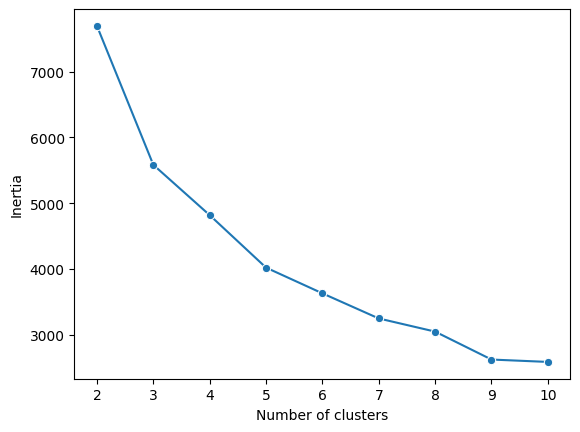

In [11]:
#create an elbow plot
#with marker = "o" points are highlighted
plot = sns.lineplot(x = num_clusters, y = inertia, marker = "o")
plot.set_xlabel("Number of clusters")
plot.set_ylabel("Inertia")

In [12]:
#compute silhouette score
sil_score = kmeans_sil(num_clusters, clusterScal)

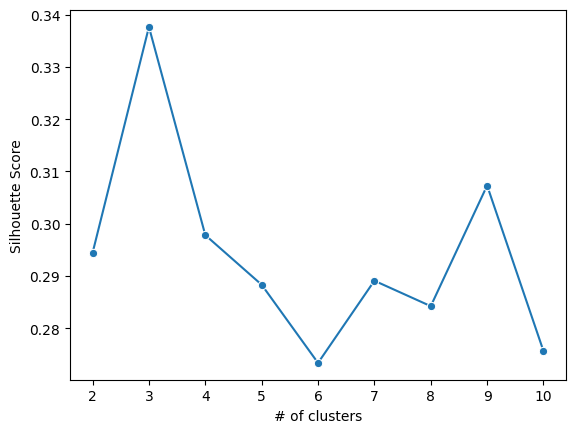

In [13]:
# Create a line plot.
plot = sns.lineplot(x=num_clusters, y=sil_score, marker='o')
plot.set_xlabel("# of clusters");
plot.set_ylabel("Silhouette Score");

Inertia and Silhouette point to 8 as an optimal value for k. That's for two reasons why:  
  
- Inertia starts to flatten around 5, yet k = 8 still notably improves it.  
- Silhouette is around 0.31 at k=8, that is acceptable for real world financial data (where clusters naturally tend to overlap). Even though it is not the highest, the model gains in intepreptability and segment richness with k=8.

Once k has been settled, it is possible to acutally implement a k-mean model.

In [14]:
#instantiate a 8-k model
kmeans5 = KMeans(n_clusters=8, random_state=42)
#fit the model
kmeans5.fit(clusterScal)

KMeans(random_state=42)

In [15]:
# Print unique labels to check if all 8 clusters are there
print('Unique labels:' , np.unique(kmeans5.labels_))

Unique labels: [0 1 2 3 4 5 6 7]


In [16]:
#transform clusterScal into a pandas df
clusterScal = pd.DataFrame(clusterScal, columns = ["Close", "Volume", "trend", "fg_index"])
#Create a new column `cluster`.
clusterScal['cluster'] = kmeans5.labels_
clusterScal.head()

,Close,Volume,trend,fg_index,cluster
0,-0.860608,-0.457193,0.603392,-0.775951,0
1,-0.874448,-0.251878,1.691120,-1.462829,5
2,-0.861575,-0.517757,0.440233,-0.318032,0
3,-0.901546,-0.476595,0.005142,-1.050702,5
4,-0.950559,-0.083797,1.582347,-1.645997,5


Let's show the features' mean for each cluster. If these prove to be insightful, we are going to add the "clusters" to the engineered dataset.

In [17]:
clusterScal.groupby('cluster').mean()

,Close,Volume,trend,fg_index
cluster,,,,
0,-0.449579,-0.347106,0.186430,-0.060982
1,2.422210,-0.476324,0.864829,0.476765
2,-0.409746,2.967382,0.909806,-0.606001
3,1.079616,-0.425256,-0.497586,0.634300
4,-0.909653,-0.395915,-1.177732,-0.497729
5,-0.231783,0.051482,0.287372,-1.169020
6,-0.737545,-0.152562,-0.577340,1.137881
7,0.407659,-0.014560,1.156615,1.188937


Clusters show meaningfull differences. More in details, the clusters have the features below:  
  
- 0: Low price & low volume during slightly greedy sentiment — possible undervalued calm period.    
- 1: Very high price, low volume — hype peak with low trading activity.  
- 2: Average market conditions but high fear — potential early crash/uncertainty.    
- 3: Average market, rising trend and strong greed — beginning of a bull market.   
- 4: High price but low trend → maybe price reversal coming.  
- 5: Low price, high volume — panic sell or accumulation? Could be a capitulation zone.  
- 6: Strong bullish regime — high everything. Likely peak momentum/bull run.  
- 7: Depressed market, low sentiment — bear market or recovery bottom.  
  
As these clusters add more information to our data, we are going to add them to our engineered df.

In [18]:
#add the clusters to the original df
df["cluster"] = kmeans5.labels_
df

,date,open,high,low,close,volume,trend,fg_index,cluster
0,2018-02-01,10285.10,10335.00,8750.99,9224.52,33564.764311,45,30.0,0
1,2018-02-02,9224.52,9250.00,8010.02,8873.03,49971.626975,65,15.0,5
2,2018-02-03,8873.03,9473.01,8229.00,9199.96,28725.000735,42,40.0,0
3,2018-02-04,9199.96,9368.00,7930.00,8184.81,32014.308449,34,24.0,5
4,2018-02-05,8179.99,8382.80,6625.00,6939.99,63403.182579,63,11.0,5
...,...,...,...,...,...,...,...,...,...
2639,2025-04-24,93691.07,94005.00,91660.01,93980.47,19497.060710,42,63.0,1
2640,2025-04-25,93980.47,95758.04,92855.96,94638.68,27500.666480,42,60.0,1
2641,2025-04-26,94638.68,95199.00,93870.69,94628.00,9415.068750,33,65.0,1
2642,2025-04-27,94628.00,95369.00,93602.58,93749.30,11162.841000,34,61.0,1


#### FEATURE MANIPULATION

Adding new features allows to tackle multicollinearity along with increasing predictive power. Starting from the variables in the original df, the new variables below will be enginereed:  
  
- log return: Measures the percentage change in price from one day to the next using the natural logarithm; helps normalize returns and account for compounding.  
- high-low spread: The difference between the daily high and low prices; captures intraday volatility.  
- Close-open spread: The difference between the closing and opening prices for the day; indicates daily price movement direction.  
- Price Momentum: The difference between the current close and a past close (e.g., 3 days ago); used to assess trend strength.  
- Volume change: The change in trading volume compared to the previous day; detects unusual market activity.
- Rolling return std: The standard deviation of log returns over a defined window (e.g., 5 days); measures recent price volatility.  

In [19]:
#log return
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
#high_low spread
df['hl_spread'] = df['high'] - df['low']
#close-open spread
df['co_spread'] = df['close'] - df['open']
#price momentum (3-days shift)
df['momentum_3'] = df['close'] - df['close'].shift(3)
#volume change
df['vol_change'] = df['volume'] - df['volume'].shift(1)
#rolling return std (5 days window)
df['rolling_std_5'] = df['log_return'].rolling(window=5).std()

The next step is to drop those rows having NaN. These are the first 5 rows, as the rolling return std goes back of 5 days.

In [20]:
#drop NaNs
df = df.dropna().reset_index(drop=True)
#show the new df
df.head(5)

,date,open,high,low,close,volume,trend,fg_index,cluster,log_return,hl_spread,co_spread,momentum_3,vol_change,rolling_std_5
0,2018-02-06,6939.63,7878.00,6000.01,7652.14,100201.500307,78,8.0,5,0.097685,1877.99,712.51,-1547.82,36798.317728,0.107546
1,2018-02-07,7655.02,8476.00,7150.01,7599.00,60778.460497,49,36.0,0,-0.006969,1325.99,-56.02,-585.81,-39423.039810,0.108378
2,2018-02-08,7599.00,7844.00,7572.09,7784.02,1521.537318,41,30.0,0,0.024056,271.91,185.02,844.03,-59256.923179,0.106621
3,2018-02-09,7789.90,8738.00,7789.90,8683.92,20482.910825,35,44.0,0,0.109400,948.10,894.02,1031.78,18961.373507,0.110290
4,2018-02-10,8683.93,9065.78,8120.00,8533.98,49381.512653,28,54.0,0,-0.017417,945.78,-149.95,934.98,28898.601828,0.058932


Once done, we can get rid of the variables we chose to drop at the beggining.

In [21]:
#drop open, low and high
df = df.drop(columns=["open", "low", "high"])
#show the df
df.head(5)

,date,close,volume,trend,fg_index,cluster,log_return,hl_spread,co_spread,momentum_3,vol_change,rolling_std_5
0,2018-02-06,7652.14,100201.500307,78,8.0,5,0.097685,1877.99,712.51,-1547.82,36798.317728,0.107546
1,2018-02-07,7599.00,60778.460497,49,36.0,0,-0.006969,1325.99,-56.02,-585.81,-39423.039810,0.108378
2,2018-02-08,7784.02,1521.537318,41,30.0,0,0.024056,271.91,185.02,844.03,-59256.923179,0.106621
3,2018-02-09,8683.92,20482.910825,35,44.0,0,0.109400,948.10,894.02,1031.78,18961.373507,0.110290
4,2018-02-10,8533.98,49381.512653,28,54.0,0,-0.017417,945.78,-149.95,934.98,28898.601828,0.058932


The final step is to examine multicollinearity in the upadted df. Both VIF and multicollinearity matrix will be used.

In [22]:
check_multicollinearity(df, method = "correlation")

(                  close    volume     trend  fg_index   cluster  log_return  \
 close          1.000000 -0.157000  0.261603  0.368757 -0.168300    0.021041   
 volume        -0.157000  1.000000  0.369485 -0.136242 -0.053569   -0.008107   
 trend          0.261603  0.369485  1.000000  0.107512  0.012662    0.014405   
 fg_index       0.368757 -0.136242  0.107512  1.000000  0.153493    0.039257   
 cluster       -0.168300 -0.053569  0.012662  0.153493  1.000000    0.022831   
 log_return     0.021041 -0.008107  0.014405  0.039257  0.022831    1.000000   
 hl_spread      0.692967  0.073077  0.421754  0.238550  0.023927   -0.037525   
 co_spread      0.045440 -0.014852  0.019426  0.021246  0.002947    0.755968   
 momentum_3     0.078434 -0.019954  0.040488  0.223338  0.027148    0.439254   
 vol_change    -0.002227  0.239403  0.085562  0.003306 -0.034959   -0.045155   
 rolling_std_5 -0.078076  0.191173  0.188761 -0.111732  0.167959   -0.033131   
 
                hl_spread  co_spread  

In [23]:
check_multicollinearity(df, method = "vif")

,feature,VIF
0,close,6.127049
1,volume,2.341388
2,trend,5.826699
3,fg_index,6.057134
4,cluster,3.908487
5,log_return,2.347644
6,hl_spread,4.764448
7,co_spread,2.842289
8,momentum_3,1.574896
9,vol_change,1.173294


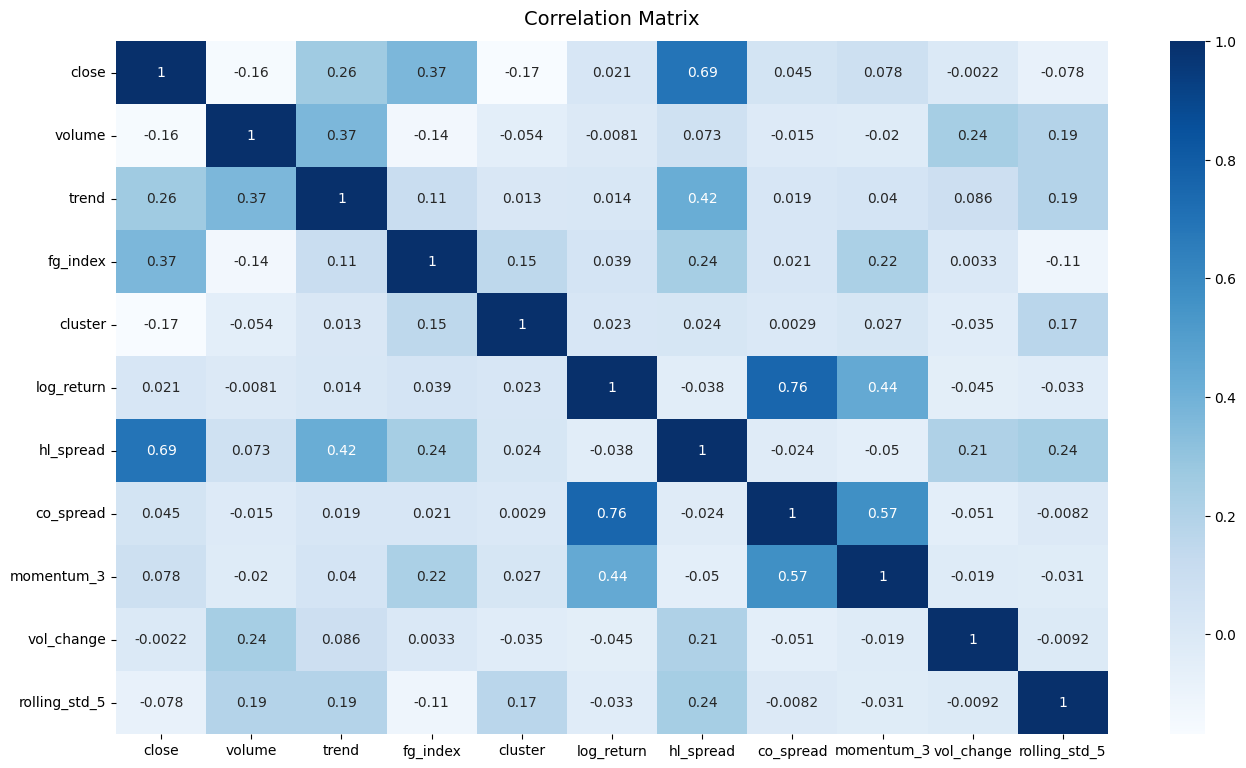

In [24]:
# Plot a correlation heatmap
plt.figure(figsize=(16, 9))
crldf = df.drop(["date"], axis = 1)
crl_plot = sns.heatmap(crldf.corr(), annot=True, cmap=sns.color_palette('Blues', as_cmap=True))
crl_plot.set_title('Correlation Matrix', fontdict={'fontsize':14}, pad=12);

co_spread is the variable rising more concerns when it comes to correlation with other regressors. As a consequence, it will be removed from the dataset. That's for two reasons why:  
  
- It adds limited unique signal (as open and close are already captured by log returns and momentum)  
- It is highly correlated with log return and momentum-3  

In [25]:
#drop co_spread
df = df.drop(columns = "co_spread")
df.head(5)


,date,close,volume,trend,fg_index,cluster,log_return,hl_spread,momentum_3,vol_change,rolling_std_5
0,2018-02-06,7652.14,100201.500307,78,8.0,5,0.097685,1877.99,-1547.82,36798.317728,0.107546
1,2018-02-07,7599.00,60778.460497,49,36.0,0,-0.006969,1325.99,-585.81,-39423.039810,0.108378
2,2018-02-08,7784.02,1521.537318,41,30.0,0,0.024056,271.91,844.03,-59256.923179,0.106621
3,2018-02-09,8683.92,20482.910825,35,44.0,0,0.109400,948.10,1031.78,18961.373507,0.110290
4,2018-02-10,8533.98,49381.512653,28,54.0,0,-0.017417,945.78,934.98,28898.601828,0.058932


In [26]:
df.tail()

,date,close,volume,trend,fg_index,cluster,log_return,hl_spread,momentum_3,vol_change,rolling_std_5
2634,2025-04-24,93980.47,19497.06071,42,63.0,1,0.003084,2344.99,6464.24,-7907.10737,0.027673
2635,2025-04-25,94638.68,27500.66648,42,60.0,1,0.006979,2902.08,1195.69,8003.60577,0.026803
2636,2025-04-26,94628.00,9415.06875,33,65.0,1,-0.000113,1328.31,936.92,-18085.59773,0.028010
2637,2025-04-27,93749.30,11162.84100,34,61.0,1,-0.009329,1766.42,-231.17,1747.77225,0.006127
2638,2025-04-28,95011.18,22157.53351,42,54.0,1,0.013370,2829.99,372.50,10994.69251,0.008439


At the end, the dataset is composed by: close, volumne, trend, fg_index, cluster, log_return, hl_spread, momentum_3, vol_change and rolling_std_5.  
  
What is missing is a target variable for crypto volatility.

## TARGET VARIABLE (Y)

The analysis main goal is to forecast crypto volatility. Hence, the target variable must reflect future volatility over a given horizon. 

To do that, considering Future Rolling Volatility as a proxy is often considered as a solid choice. In this specific case, the 21-days future rolling volatility will be the target variable.

Let's compute it and add it to the df. As done above, we must remove the first 5 rows of the new df as they are going to be NaNs.

In [40]:
#compute volatility
df['volatility30'] = df['log_return'].rolling(window=30).std().shift(-30)
#show the df
df = df.dropna().reset_index(drop=True)
df.head(5)

,date,close,volume,trend,fg_index,cluster,log_return,hl_spread,momentum_3,vol_change,rolling_std_5,volatility30
0,2018-02-06,7652.14,100201.500307,78,8.0,5,0.097685,1877.99,-1547.82,36798.317728,0.107546,0.056942
1,2018-02-07,7599.00,60778.460497,49,36.0,0,-0.006969,1325.99,-585.81,-39423.039810,0.108378,0.056926
2,2018-02-08,7784.02,1521.537318,41,30.0,0,0.024056,271.91,844.03,-59256.923179,0.106621,0.057762
3,2018-02-09,8683.92,20482.910825,35,44.0,0,0.109400,948.10,1031.78,18961.373507,0.110290,0.056305
4,2018-02-10,8533.98,49381.512653,28,54.0,0,-0.017417,945.78,934.98,28898.601828,0.058932,0.056821


In [41]:
df.tail(60)

,date,close,volume,trend,fg_index,cluster,log_return,hl_spread,momentum_3,vol_change,rolling_std_5,volatility30
2549,2025-01-29,103733.24,23155.35802,52,72.0,1,0.023386,3454.67,1113.24,1133.30037,0.016022,0.019950
2550,2025-01-30,104722.94,19374.07472,53,70.0,1,0.009496,3178.90,2640.11,-3781.28330,0.016877,0.020342
2551,2025-01-31,102429.56,21983.18193,54,76.0,1,-0.022143,4452.00,1094.04,2609.10721,0.017380,0.026817
2552,2025-02-01,100635.65,12290.95747,43,68.0,1,-0.017669,2504.20,-3097.59,-9692.22446,0.019058,0.031041
2553,2025-02-02,97700.59,34619.49939,60,60.0,1,-0.029599,5306.60,-7022.35,22328.54192,0.022632,0.030844
2554,2025-02-03,101328.52,75164.73850,92,44.0,1,0.036460,11269.01,-1101.04,40545.23911,0.027332,0.030886
2555,2025-02-04,97763.13,40267.98697,63,72.0,1,-0.035820,5582.31,-2872.52,-34896.75153,0.028919,0.030298
2556,2025-02-05,96612.43,26233.30444,54,54.0,1,-0.011840,2994.00,-1088.16,-14034.68253,0.028536,0.030842
2557,2025-02-06,96554.35,23515.20405,50,49.0,1,-0.000601,3443.36,-4774.17,-2718.10039,0.028663,0.030842
2558,2025-02-07,96506.80,31794.22065,49,44.0,1,-0.000493,4517.65,-1256.33,8279.01660,0.026091,0.032840


Let's save the engineered dataset.

In [29]:
#save in csv
df.to_csv("../data/crypto_volatility30_fe.csv", index = False)
#save in parquet
df.to_parquet("../data/crypto_volatility30_fe.parquet", index = False)

Finally, the target variable shall be divided by the predictors.

In [30]:
#define the target variable (y)
y = df['volatility30']
#define the regressors
x = df.copy()
x = x.drop(['volatility30'], axis = 1)
x.head()

,date,close,volume,trend,fg_index,cluster,log_return,hl_spread,momentum_3,vol_change,rolling_std_5
0,2018-02-06,7652.14,100201.500307,78,8.0,5,0.097685,1877.99,-1547.82,36798.317728,0.107546
1,2018-02-07,7599.00,60778.460497,49,36.0,0,-0.006969,1325.99,-585.81,-39423.039810,0.108378
2,2018-02-08,7784.02,1521.537318,41,30.0,0,0.024056,271.91,844.03,-59256.923179,0.106621
3,2018-02-09,8683.92,20482.910825,35,44.0,0,0.109400,948.10,1031.78,18961.373507,0.110290
4,2018-02-10,8533.98,49381.512653,28,54.0,0,-0.017417,945.78,934.98,28898.601828,0.058932


# DATA SPLITTING

In order to ensure the model is not biased and to assess its performances, the dataset should be split into training-validation-testing. The model will be trained on the training data; through the validation set its performances are assessed and the best model is chosen; and the test data is used to check how the model performs on unsees data.  
  
For these purposes, the splitting percentages will be the following:  
  
- training 60% (x_tr)  
- validation 20% (x_val)  
- testing 20% (x_tt)  

In [31]:
# Ensure data is sorted by date
x = x.sort_values('date').reset_index(drop=True)
y = y.sort_index().reset_index(drop=True)  # Match x if needed

In [32]:
#define the windows length
#total size
n = len(x)
#train size (60%)
train_size = int(n * 0.6)
#validation size (20%)
val_size = int(n * 0.2)

In [33]:
# Split into train, validation, test
X_tr = x.iloc[:train_size]
y_tr = y.iloc[:train_size]

X_val = x.iloc[train_size:train_size + val_size]
y_val = y.iloc[train_size:train_size + val_size]

X_tt = x.iloc[train_size + val_size:]
y_tt = y.iloc[train_size + val_size:]

In [34]:
# Reset index for all splits
X_tr = X_tr.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_tt = X_tt.reset_index(drop=True)
y_tr = y_tr.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_tt = y_tt.reset_index(drop=True)

In [35]:
#save the x
X_tr.to_csv("../data/unscaled_data/X_tr30.csv", index=True)
X_val.to_csv("../data/unscaled_data/X_val30.csv", index=True)
X_tt.to_csv("../data/unscaled_data/X_tt30.csv", index=True)
#save the y
y_tr.to_csv("../data/unscaled_data/y_tr30.csv", index=True)
y_val.to_csv("../data/unscaled_data/y_val30.csv", index=True)
y_tt.to_csv("../data/unscaled_data/y_tt30.csv", index=True)

# SCALING - FEATURE TRANSFORMATION

Some models require data to be within the same scale. As variables in the dataset have wide differences between their ranges, it is necessary to scale the df's features.  
  
Note the sclaing process is performed after data splitting to avoid data leakages that could lead to overly optimistic performance estimates. Thus, the scaler is fitted on the training data and then employed to scale all the other sets.  

In [36]:
# Scaling all 3 sets and keeping boolean unchanged
num_cols = X_tr.select_dtypes(include=["int64", "float64"]).columns
# Initialize StandardScaler
scaler = StandardScaler()
# Create copies to keep original structure
X_tr_scal = X_tr.copy()
X_val_scal = X_val.copy()
X_tt_scal = X_tt.copy()
# Fit scaler on training data & transform all sets
X_tr_scal[num_cols] = scaler.fit_transform(X_tr[num_cols])  # Fit + transform on training
X_val_scal[num_cols] = scaler.transform(X_val[num_cols])    # Transform validation
X_tt_scal[num_cols] = scaler.transform(X_tt[num_cols])      # Transform test
# Display the transformed dataframes
print("Scaled Training dataset:")
print(X_tr_scal.head())
print()
print("Scaled Validation dataset:")
print(X_val_scal.head())
print()
print("Scaled testing dataset:")
print(X_tt_scal.head())

Scaled Training dataset:
         date     close    volume     trend  fg_index  cluster  log_return  \
0  2018-02-06 -0.709713  1.304515  2.772724 -1.599959        5    2.447036   
1  2018-02-07 -0.712639  0.167790  1.112525 -0.366413        0   -0.200259   
2  2018-02-08 -0.702451 -1.540825  0.654539 -0.630744        0    0.584540   
3  2018-02-09 -0.652900 -0.994093  0.311050 -0.013971        0    2.743379   
4  2018-02-10 -0.661156 -0.160830 -0.089688  0.426581        0   -0.464562   

   hl_spread  momentum_3  vol_change  rolling_std_5  
0   0.444661   -0.900433    1.360593       3.427859  
1   0.070217   -0.355923   -1.459929       3.466548  
2  -0.644808    0.453385   -2.193869       3.384871  
3  -0.186121    0.559654    0.700548       3.555369  
4  -0.187695    0.504864    1.068269       1.169061  

Scaled Validation dataset:
         date     close    volume     trend  fg_index  cluster  log_return  \
0  2022-06-08  0.532110  0.391662 -0.433177 -1.203462        5   -0.783413  

The target should be scaled too.

In [37]:
# Fit scaler only on training set
scaler_y = StandardScaler()
y_tr_scal = pd.DataFrame(scaler_y.fit_transform(y_tr.values.reshape(-1, 1)), columns=['target'])
# Then transform validation and test using the same scaler
y_val_scal = pd.DataFrame(scaler_y.transform(y_val.values.reshape(-1, 1)), columns=['target'])
y_tt_scal = pd.DataFrame(scaler_y.transform(y_tt.values.reshape(-1, 1)), columns=['target'])

# Display the transformed dataframes
print("Scaled Training dataset:")
print(y_tr_scal.head())
print()
print("Scaled Validation dataset:")
print(y_val_scal.head())
print()
print("Scaled testing dataset:")
print(y_tt_scal.head())

Scaled Training dataset:
     target
0  1.418397
1  1.417277
2  1.475789
3  1.373831
4  1.409940

Scaled Validation dataset:
     target
0  0.766709
1  0.768156
2  0.768118
3  0.791456
4  0.722805

Scaled testing dataset:
     target
0 -0.860462
1 -0.829150
2 -0.833849
3 -0.796837
4 -0.934220


To conclude, let's save the scaled datasets in the scaled_data folder.

In [38]:
#save the x
X_tr_scal.to_csv("../data/scaled_data/X_tr_scal30.csv", index=True)
X_val_scal.to_csv("../data/scaled_data/X_val_scal30.csv", index=True)
X_tt_scal.to_csv("../data/scaled_data/X_tt_scal30.csv", index=True)
#save the y
y_tr_scal.to_csv("../data/scaled_data/y_tr_scal30.csv", index=True)
y_val_scal.to_csv("../data/scaled_data/y_val_scal30.csv", index=True)
y_tt_scal.to_csv("../data/scaled_data/y_tt_scal30.csv", index=True)
#save the scalers
joblib.dump(scaler, '../data/scaler_x.pkl')
joblib.dump(scaler_y, '../data/scaler_y.pkl')

['../data/scaler_y.pkl']